In [5]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx, serialization
import optax

from typing import Callable
from time import time
import matplotlib.pyplot as plt

from fmmax import basis, fmm, fields, scattering
import refractiveindex2 as ri

In [17]:
jax.config.update("jax_default_matmul_precision", "float32")

## Simulation function

In [18]:
SIO2 = ri.RefractiveIndexMaterial(shelf="main", book="SiO2", page="Malitson")
SI3N4 = ri.RefractiveIndexMaterial(shelf="main", book="Si3N4", page="Luke")


def prepare_lens_scattering_solver(
        wavelength: float,
        period: float,
        lens_thickness: float,
        substrate_thickness: float,
        approximate_number_of_terms: int,
        propagate_by_distance: float = 0.
):
    lens_permittivity = SI3N4.get_refractive_index(wavelength_um=wavelength / 1000) ** 2
    permittivity_substrate = SIO2.get_refractive_index(wavelength_um=wavelength / 1000) ** 2

    primitive_lattice_vectors = basis.LatticeVectors(
        u=period * basis.X, v=period * basis.Y
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_number_of_terms,
        truncation=basis.Truncation.CIRCULAR,
    )

    basis_indices_norm = np.linalg.norm(expansion.basis_coefficients, axis=-1)
    n_propagating_waves = np.count_nonzero(basis_indices_norm < period / wavelength)

    in_plane_wavevector = jnp.array([0., 0.])
    solve_result_ambient = fmm.eigensolve_isotropic_media(
        permittivity=jnp.atleast_2d(1.),
        wavelength=jnp.asarray(wavelength),
        in_plane_wavevector=in_plane_wavevector,
        primitive_lattice_vectors=primitive_lattice_vectors,
        expansion=expansion,
        formulation=fmm.Formulation.FFT
    )
    solve_result_substrate = fmm.eigensolve_isotropic_media(
        permittivity=jnp.atleast_2d(permittivity_substrate),
        wavelength=jnp.asarray(wavelength),
        in_plane_wavevector=in_plane_wavevector,
        primitive_lattice_vectors=primitive_lattice_vectors,
        expansion=expansion,
        formulation=fmm.Formulation.FFT
    )
    inc_fwd_amplitude = jnp.zeros(2 * len(expansion.basis_coefficients))
    zero_mode_index, = jnp.where(jnp.all(expansion.basis_coefficients == 0, axis=1))
    inc_fwd_amplitude = inc_fwd_amplitude.at[zero_mode_index].set(1.)
    fwd_amplitude = jnp.asarray(inc_fwd_amplitude[..., jnp.newaxis], dtype=float)

    def lens_pattern_to_scattered_amps_func(lens_pattern: jnp.ndarray) -> jnp.ndarray:
        lens_permittivity_pattern = lens_pattern * (lens_permittivity - 1.) + 1.
        solve_result_crystal = fmm.eigensolve_isotropic_media(
            permittivity=lens_permittivity_pattern,
            wavelength=jnp.asarray(wavelength),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            expansion=expansion,
            formulation=fmm.Formulation.FFT
        )
        s_matrices_interior = scattering.stack_s_matrices_interior(
            layer_solve_results=[
                solve_result_ambient, solve_result_substrate, solve_result_crystal, solve_result_ambient],
            layer_thicknesses=[0., substrate_thickness, lens_thickness, 0.]  # type: ignore[arg-type]
        )
        amplitudes_interior = fields.stack_amplitudes_interior(
            s_matrices_interior=s_matrices_interior,
            forward_amplitude_0_start=jnp.zeros_like(fwd_amplitude),
            backward_amplitude_N_end=fwd_amplitude,
        )
        _, trans_amps = amplitudes_interior[0]

        if propagate_by_distance != 0:
            trans_amps = fields.propagate_amplitude(
                amplitude=trans_amps,
                distance=propagate_by_distance,  # type: ignore[arg-type]
                layer_solve_result=solve_result_ambient
            )

        te, th = fields.fields_from_wave_amplitudes(
            forward_amplitude=jnp.zeros_like(trans_amps),
            backward_amplitude=trans_amps,
            layer_solve_result=solve_result_ambient
        )
        trans_e_x, trans_e_y, _ = te
        propagating_trans_e_x_amps = trans_e_x[:n_propagating_waves].flatten()
        propagating_trans_e_y_amps = trans_e_y[:n_propagating_waves].flatten()

        ref_amps, _ = amplitudes_interior[-1]
        re, rh = fields.fields_from_wave_amplitudes(
            forward_amplitude=ref_amps,
            backward_amplitude=jnp.zeros_like(ref_amps),
            layer_solve_result=solve_result_ambient
        )
        return jnp.array([
            (te[0].squeeze(), te[1].squeeze(), te[2].squeeze()),
            (th[0].squeeze(), th[1].squeeze(), th[2].squeeze()),
            (re[0].squeeze(), re[1].squeeze(), re[2].squeeze()),
            (rh[0].squeeze(), rh[1].squeeze(), rh[2].squeeze())
        ])

        return propagating_trans_e_y_amps

    return lens_pattern_to_scattered_amps_func, expansion.basis_coefficients[:n_propagating_waves]

## Load lens geometries and prepare the simulation

In [19]:
patterns = np.load('freeform_training_patterns_32bit.npy')
print(patterns.shape)
permutation = jax.random.permutation(jax.random.key(0), patterns.shape[0])

(33792, 100, 100)


In [40]:
color = 'blue'
period = 2000

color_to_wavelength_dict = {
    'red': 650,
    'green': 550,
    'blue': 450
}
wavelength = color_to_wavelength_dict[color]
p = period / wavelength

In [41]:
sim_f, expansion = prepare_lens_scattering_solver(
    wavelength=wavelength,
    period=period,
    lens_thickness=600,
    substrate_thickness=500,
    approximate_number_of_terms=600,
)
sim_f_jit = jax.jit(sim_f)

n_propagating = len(expansion)
kx, ky = (expansion / p).T
kz = np.sqrt(1 - kx ** 2 - ky ** 2)

## Test presision on GPU

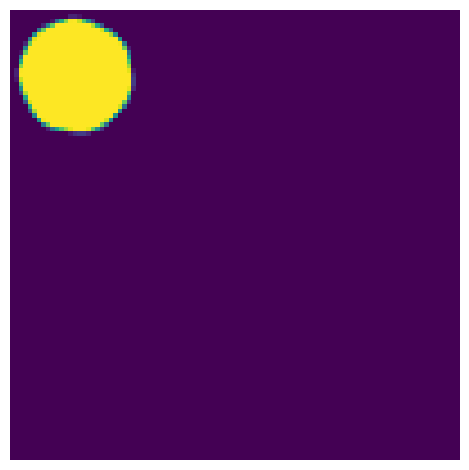

In [43]:
worst_i = 18692
# worst_i = 29369
worst_pattern = patterns[permutation[worst_i]]

plt.imshow(worst_pattern)
plt.axis('off')
plt.tight_layout()
plt.show()

In [44]:
worst_lens_amps = sim_f(worst_pattern)
worst_lens_t = worst_lens_amps[0, ..., :n_propagating]
worst_lens_r = worst_lens_amps[2, ..., :n_propagating]
worst_lens_amps_norm = np.sum(np.abs(worst_lens_t) ** 2, axis=0) + np.sum(np.abs(worst_lens_r) ** 2, axis=0)
worst_lens_total_power = np.sum(worst_lens_amps_norm * kz, axis=-1)
print(worst_lens_total_power)

1.0001487505856028


In [46]:
color, wavelength, n_propagating

('blue', 450, 61)

## Simulate all lenses in the training set

In [47]:
amps = []

try:
    for i in range(patterns.shape[0]):
        start = time()
        amps_i = sim_f_jit(patterns[permutation[i]])
        amps_i.block_until_ready()
        amps.append(amps_i)
        if i % 10 == 0:
            print(i, time() - start)
except KeyboardInterrupt:
    pass

n_completed = len(amps)
n_completed

amps = np.array(amps)
np.save(f'{color}_freeform_accurate.npy', amps)

0 133.80095648765564
10 0.36667394638061523
20 0.37546253204345703
30 0.3667714595794678
40 0.3762943744659424
50 0.3715953826904297
60 0.42066121101379395
70 0.3671417236328125
80 0.3709750175476074
90 0.37296128273010254
100 0.3761768341064453
110 0.37468934059143066
120 0.3739748001098633
130 0.36659717559814453
140 0.3761119842529297
150 0.3689873218536377
160 0.3606719970703125
170 0.38291025161743164
180 0.3688483238220215
190 0.3700675964355469
200 0.3692042827606201
210 0.3690211772918701
220 0.3722529411315918
230 0.3782956600189209
240 0.37508535385131836
250 0.36043667793273926
260 0.370481014251709
270 0.37610697746276855
280 0.3722105026245117
290 0.3639383316040039
300 0.3672614097595215
310 0.36980509757995605
320 0.3662881851196289
330 0.37560105323791504
340 0.37816929817199707
350 0.3794858455657959
360 0.3701930046081543
370 0.37145018577575684
380 0.3769516944885254
390 0.37179136276245117
400 0.368497371673584
410 0.37731313705444336
420 0.3737790584564209
430 0.37

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

